<a href="https://colab.research.google.com/github/LnTheSanchari/Linear-Regression-From-Scratch/blob/main/Linear_Regression_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Simple Linear Regression**

For a given set of data points
$$\{(x^{(1)}, y^{(1)}), \ldots, (x^{(n)}, y^{(n)})\}$$

In the linear regression model, we assume that $y$ can be **approximated** by a linear function of $x$.. That is
$$y^{(i)} \approx b + w x^{(i)}$$
However, the observed points may not lie exactly on a straight line. Therefore, we seek a line that best approximates the observed data. This model is commonly known as **simple linear regression mode**l.  The parameters $w, b$ are the parameters of this Simple Linear Regression mode.



> But how we find parameters $w, b$, which gives a line that best approximates the observed data?

We need a loss function to measure how well a particular choice of $(w,b)$ fits the observed data.. There are two common loss functions, the first one is:  **"Mean Squared Error Loss function"**


$$\mathcal{L}(w, b) = \dfrac{1}{n}\sum_{i=1}^{n}(y^{(i)} - (wx^{(i)} + b))^2$$

Another commonly used performance metric is **"Mean Absolute Error Loss Function"**, instead of taking square of residuls, we take absolute of residuals.

$$\bar{\mathcal{L}}(w, b) = \dfrac{1}{n}\sum_{i=1}^{n}|y^{(i)} - (wx^{(i)} + b)|$$



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
plt.style.use('ggplot')

## Load Dataset

In [460]:
url = 'https://raw.githubusercontent.com/LnTheSanchari/Linear-Regression-From-Scratch/main/house_price_regression_dataset.csv'

In [461]:
data = (pd.read_csv(url).head(50)).to_numpy()

In [453]:
X = data[::, 0].reshape(-1, 1)

In [454]:
Y = data[::, -1].reshape(-1, 1)

In [455]:
print(X.shape, Y.shape)

(50, 1) (50, 1)


## **Train and Test Split**


In [456]:
from sklearn.model_selection import train_test_split

In [457]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y,
                                                    train_size=0.7,
                                                    random_state=42)

In [458]:
print(X_train.shape, Y_train.shape)

(35, 1) (35, 1)


In [459]:
print(X_test.shape, Y_test.shape)

(15, 1) (15, 1)


## **Compute Loss**

In [ ]:
def simple_reg_compute_MSE(x_train, y_train, w, b):
    n = x_train.shape[0] #number of training examples
    y_pred = w*x_train + b #numpy broadcasting
    loss = ((y_train - y_pred)**2).sum()
    return (1/n)*loss

In [ ]:
def simple_reg_compute_MAE(x_train, y_train, w, b):
    n = x_train.shape[0] #number of training examples
    y_pred = w*x_train + b #numpy broadcasting
    loss = np.abs(y_train - y_pred).sum()
    return (1/n)*loss

In [ ]:
simple_reg_compute_MSE(X_train, Y_train, 100, 200)

np.float64(124773606729.45891)

In [ ]:
simple_reg_compute_MAE(X_train, Y_train, 10, 2)

np.float64(574252.2716438366)

In [ ]:
def simple_reg_line_plot(x_train, y_train, w, b):
    plt.scatter(x_train, y_train, marker='x')
    plt.plot(x_train, w*x_train + b, color='green')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Simple Linear Regression')
    plt.show()

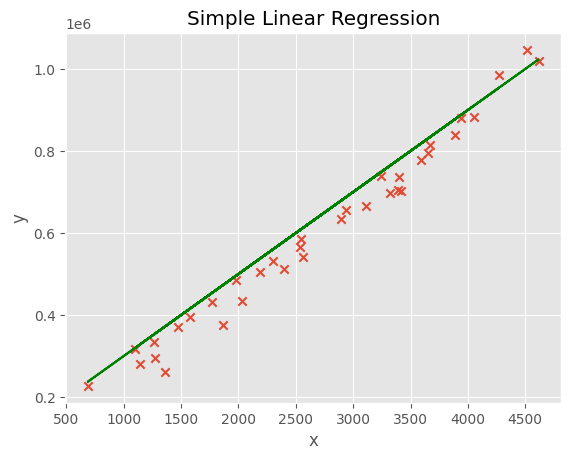

In [ ]:
simple_reg_line_plot(X_train, Y_train, 200, 1e+05)

By this point, you might have already guessed that our objective in the Linear Regression Model is to find the parameters that minimize the chosen loss function. That is,

$$\arg \min_{w, b} \mathcal{L}(w, b)$$

> But how do we find such parameters?

The below derivation considers, the chosen loss function is MSE.

## **Minimization**

 We can try multivariate calculus and frustrating algebra, then get the answer. But **matrix calculus** really saves us here.

In linear algebra, whenever we encounter expression like $$\sum_{i=1}^{n}x_i^2$$
It should remind us that: $\textbf{x}^T \textbf{x}$ equals that sum, where
$$\mathrm{x} = \begin{bmatrix}x_1 & \ldots & x_n\end{bmatrix}^T$$

Carefully, observe the Mean squared error loss function. With some observation we can conclude that i can be written as follows:

$$\mathcal{L}(\mathrm{x}) = \dfrac{1}{n}||A\hat{\mathrm{x}} - \mathrm{y}||_2^2$$
where
$$A = \begin{bmatrix}x^{(1)} & 1\\ \vdots  & \vdots \\x^{(n)} & 1 \end{bmatrix}, \mathrm{y} = \begin{bmatrix}y^{(1)} \\ \vdots \\ y^{(n)}\end{bmatrix}, \hat{\mathrm{x}} = \begin{bmatrix}w \\ b\end{bmatrix}$$



### Note

If you're not particularly interested in the matrix calculus derivation, you can instead watch MIT 18.06's lecture on [Projection](https://www.youtube.com/watch?v=osh80YCg_GM&list=PL221E2BBF13BECF6C&index=35).

Professor Gilbert Strang takes a geometric approach and shows how the idea of **projection** naturally leads to the **Normal Equation**.



### **Matrix Calculus**





 Recall few facts from matrix calculus:

*   $d(\mathrm{x}^T\mathrm{x})  = 2\mathrm{x}^Td\mathrm{x}$
*   $d(g(\mathrm{x})h(\mathrm{x})) = dg* h(\mathrm{x}) + g(\mathrm{x})*dh$
*   $d(g(h(\mathrm{x}))) = g'(h(\mathrm{x}))h'(\mathrm{x})d\mathrm{x}$


Using the above rules we can find the gradient of $\mathcal{L}(\hat{\mathrm{x}})$ and it equals:
$$\nabla \mathcal{L}\vert_{\hat{\mathrm{x}}} =\dfrac{2}{n}A^T(A\hat{\mathrm{x}} - {\mathrm{y}}) $$

Recall, at the local extrema points it's necessary that, graident must be equal to $0_v$. For the $\textbf{MSE}$ the potential $\hat{\mathrm{x}}$'s are those which gradient equals zero. That is those which solve the below system:
$$A^TA \hat{\mathrm{x}} = A^T {\mathrm{y}}$$
The above equation is referred as ```Normal Equation.``` Notice those $\hat{\mathrm{x}}$'s are potential candidates for global minima.

> But in this case it turns out that, every $\hat{\mathrm{x}}$ that solve the above system are the global minimizers of the Mean square error function.

> For a differentiable convex function, every point at which the gradient is zero is a global minimizer.



> **MSE loss function is a Convex function**, if at any $\hat{\mathrm{x}}$ the gradient is equals $0$ Then at that **point the function has Global Minima**.

### **Consistency and Uniqueness**

Now the big question is, Does the system
$$A^T A \hat{\mathrm{x}} = A^T \mathrm{y}$$
is consistent or NOT?


It turns out that it is always solvable, one can prove this by using following fact:

$$\operatorname{Col}(A^T A ) = \operatorname{Col}(A^T)$$

So the gradient of MSE equals to zero at least one $\hat{\mathrm{x}}$. One can ask another question, When is it unique?

Recall that Normal Equation is a consistent system, Unique solution is guarenteed if and only if The columns of the Co-efficient matrix are linearly independent. That is

$$
\begin{aligned}
\text{Unique Minimizer}
&\iff \operatorname{Null}(A^T A)=\{\mathbf{0}\} \\
&\iff \operatorname{Null}(A)=\{\mathbf{0}\} \\
&\iff \operatorname{rank}(A)=\text{number of columns of }A \\
&\iff \text{Columns of }A\text{ are linearly independent}.
\end{aligned}
$$


So, all we have to do is solve the Normal Equations to obtain the minimizer of the MSE loss function.

**Note:** This approach is specific to the squared-error loss. The Normal Equations do not directly apply to the MAE loss.

### Numpy's Support
We don't have to implement the algorithm for solving the Normal Equations ourselves. NumPy provides `np.linalg.lstsq()` to compute the least-squares solution directly.

In our case, it can be used to find the parameter vector $\hat{\mathbf{x}}$ that minimizes the MSE loss:

$$
\hat{\mathbf{x}}^*
=
\arg\min_{\hat{\mathbf{x}}}
\left\|A\hat{\mathbf{x}}-\mathbf{y}\right\|_2^2
$$

```python
np.linalg.lstsq(A, y, rcond=None)

In [ ]:
def simple_reg_soln(x_train, y_train):
    ones_col = np.ones((x_train.shape[0], 1))
    A = np.concat([x_train, ones_col], axis=1)
    return np.linalg.lstsq(A, y_train, rcond=None)[0]

In [ ]:
soln = simple_reg_soln(X_train, Y_train)

In [ ]:
w_hat = soln[0][0]
b_hat = soln[1][0]

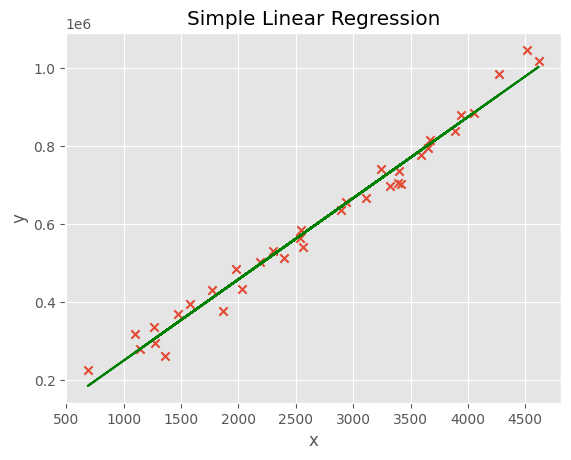

In [ ]:
simple_reg_line_plot(X_train, Y_train, w_hat, b_hat)

In [ ]:
simple_reg_compute_MSE(X_train, Y_train, soln[0][0], soln[1][0])

np.float64(927231929.1444645)

In [ ]:
simple_reg_compute_MSE(X_test, Y_test, w_hat, b_hat)

np.float64(1321763785.2728887)

Normal equation only works for MSE loss function, but what if we choose the MAE loss function, then how to get the optimal solution?

# **Gradient Descent**

There is another general approach for finding the optimal point, commonly known as **Gradient Descent**.

The basic idea of Gradient Descent is as follows:

### 1. **Choose an initial point**

First, we make a guess for the starting point. We can choose a random point, but often we simply start from the origin.

$$
\hat{\mathbf{x}}_0 \leftarrow \mathbf{0}
$$

### 2. **Compute the gradient**

At the current position, we compute the gradient of the loss function.

Recall that the gradient points in the direction of **steepest ascent**. Therefore, the negative gradient points in the direction of **steepest descent**—the direction in which the function decreases most rapidly locally.

So, we update our current point by moving in the direction opposite to the gradient:

$$
\hat{\mathbf{x}}_{k+1}
\leftarrow
\hat{\mathbf{x}}_k
-
\alpha \nabla \mathcal{L}(\hat{\mathbf{x}}_k)
$$

where $\alpha$ is called the **Learning Rate**.

The learning rate is extremely important because it controls the size of the step we take in the direction of descent.



## **Learning Rate**

Intuitively, the learning rate determines **how large a step we take at each iteration**.

- **Learning rate too small:** The algorithm takes very small steps and may require a large number of iterations to reach the optimal point.

- **Learning rate too large:** The algorithm can take steps that are too large and overshoot the optimal point. If the learning rate is sufficiently large, the algorithm may even **diverge instead of converging**.

Thus, Gradient Descent repeatedly follows the negative gradient until we reach, or get sufficiently close to, the optimal point.

## **Example**

Let's see an example. Consider the following function:
$$f(x_1, x_2) = x_1^2 + x_2^2$$

Then its gradient is:
$$\nabla f(x_1, x_2) = 2 \begin{bmatrix}x_1 \\ x_2 \end{bmatrix}$$
The graph of $f$ looks like an upward bowl and its convex function with global minima at origin. So let's apply gradient descent with different learning rates.

In [468]:
def example_gradient_descent(x_hat, learning_rate, steps):
    log_interval = 0.2*steps
    for step in range(1, steps+1):
        x_hat = x_hat - learning_rate*2*x_hat
        if step%log_interval==0:
            print(f"Step number: {step},\nx_hat:\n{x_hat},\nfunction value:{(x_hat**2).sum()}\n")
    return x_hat


In [469]:
x_hat = np.array([10, 10])

In [474]:
example_gradient_descent(x_hat, 0.9, 100)

Step number: 20,
x_hat:
[0.11529215 0.11529215],
function value:0.026584559915698417

Step number: 40,
x_hat:
[0.00132923 0.00132923],
function value:3.5336941295567924e-06

Step number: 60,
x_hat:
[1.53249554e-05 1.53249554e-05],
function value:4.697085165547712e-10

Step number: 80,
x_hat:
[1.76684706e-07 1.76684706e-07],
function value:6.243497100632052e-14

Step number: 100,
x_hat:
[2.03703598e-09 2.03703598e-09],
function value:8.299031137762087e-18



array([2.03703598e-09, 2.03703598e-09])

In [475]:
example_gradient_descent(x_hat, 1.1, 60)

Step number: 12,
x_hat:
[89.16100448 89.16100448],
function value:15899.36944067822

Step number: 24,
x_hat:
[794.96847203 794.96847203],
function value:1263949.7430558621

Step number: 36,
x_hat:
[7088.01874985 7088.01874985],
function value:100480019.59647742

Step number: 48,
x_hat:
[63197.48715279 63197.48715279],
function value:7987844764.854904

Step number: 60,
x_hat:
[563475.14353167 563475.14353167],
function value:635008474756.0779



array([563475.14353167, 563475.14353167])

In [476]:
example_gradient_descent(x_hat, 0.000001, 3000)

Step number: 600,
x_hat:
[9.98800719 9.98800719],
function value:199.52057506062673

Step number: 1200,
x_hat:
[9.97602875 9.97602875],
function value:199.04229936261692

Step number: 1800,
x_hat:
[9.96406469 9.96406469],
function value:198.56517015109287

Step number: 2400,
x_hat:
[9.95211497 9.95211497],
function value:198.08918467778645

Step number: 3000,
x_hat:
[9.94017958 9.94017958],
function value:197.61434020101214



array([9.94017958, 9.94017958])

For the above  examples explains why Learning rate matter, if step size is very large then it starts diverging. If its too small, then it take many iterations to converge to optimal point. **Learning rate matters alot**.

# **Optimization and Contours**
Recall the MSE of simple linear regression is:
$$\mathcal{L}(w, b) = \dfrac{1}{n}\sum_{i=1}^n(wx^{(i)} + b - y^{(i)})^2$$
Then the graident of MSE is:
$$\nabla \mathcal{L}_{w} = \dfrac{2}{n}\sum_{i=1}^n(wx^{(i)} + b - y^{(i)})x^{(i)}$$
$$\nabla \mathcal{L}_{b} = \dfrac{2}{n}\sum_{i=1}^n(wx^{(i)} + b - y^{(i)})$$

In [ ]:
def simple_reg_gradient(x_train, y_train, w, b):
    """
    Compute the gradient of MSE at given w, b.
    """
    n = x_train.shape[0]
    y_hat = w*x_train  + b
    grad_w = (2/n)*(((y_hat - y_train)*x_train).sum())
    grad_b = (2/n)*((y_hat - y_train).sum())
    return grad_w, grad_b

In [ ]:
w = 0
b = 0

In [ ]:
simple_reg_gradient(X_train, Y_train, w, b)

(np.float64(-3705149560.5472865), np.float64(-1202219.4004305305))

In [ ]:
def simple_reg_gradient_descent(x_train, y_train, w, b,
                                learning_rate, steps):
    loss = lambda w, b: simple_reg_compute_MSE(x_train, y_train, w, b)
    per_step = np.floor(0.1*steps)
    for step in range(1, steps+1):
        grad_w, grad_b = simple_reg_gradient(x_train, y_train, w, b)
        w = w - learning_rate*grad_w
        b = b - learning_rate*grad_b
        if step%per_step==0:
            print(f"Step number: {step},\nw:\n{w},\nb:\n{b},\nloss:\n{loss(w, b)}\n")

    return w, b

In [ ]:
simple_reg_gradient_descent(X_train, Y_train, 0, 0, 0.0000001, 2_00_000)

Step number: 20000,
w:
221.67415752416846,
b:
23.1619163391049,
loss:
1170363171.3740532

Step number: 40000,
w:
221.66674126827274,
b:
46.23994515323426,
loss:
1170096873.6365657

Step number: 60000,
w:
221.65932907494258,
b:
69.3053320079705,
loss:
1169830867.570704

Step number: 80000,
w:
221.6519209419526,
b:
92.35808382847922,
loss:
1169565152.8570073

Step number: 100000,
w:
221.6445168670786,
b:
115.39820753612912,
loss:
1169299729.176359

Step number: 120000,
w:
221.63711684809743,
b:
138.42571004850078,
loss:
1169034596.2099998

Step number: 140000,
w:
221.62972088278744,
b:
161.44059827938233,
loss:
1168769753.639511

Step number: 160000,
w:
221.6223289689281,
b:
184.44287913878003,
loss:
1168505201.1468277

Step number: 180000,
w:
221.6149411042999,
b:
207.4325595329055,
loss:
1168240938.414234

Step number: 200000,
w:
221.60755728668477,
b:
230.40964636419682,
loss:
1167976965.1243575



(np.float64(221.60755728668477), np.float64(230.40964636419682))

We made $2,00,000$ steps, yet we haven't reached the optimal point. Intuitively the reason the surface of MSE loss function has very high curvature in one direction and relatively flat in another direction. The contour plots explains why even after 200,000 steps, we are nowhere the optimal point.

In [ ]:
def simple_reg_contour_plot(x_train, y_train, colormap):
    """
    Plot the contour of MSE centered at optimal point obtained by solving
    normal equation.
    """
    optimal = simple_reg_soln(x_train, y_train)
    w_hat = optimal[0][0]
    b_hat = optimal[1][0]
    w_val = np.linspace(w_hat -5, w_hat + 5)
    b_val = np.linspace(b_hat -5, b_hat + 5)
    W, B = np.meshgrid(w_val, b_val)
    loss_func = np.vectorize(lambda w, b: simple_reg_compute_MSE(x_train,
                                                                 y_train,w, b))
    contour = plt.contour(W, B, loss_func(W, B), levels=8,
                          cmap=colormap)
    contour.clabel()
    plt.plot(w_hat, b_hat, 'x', color='red')
    plt.xlabel(r'$w$')
    plt.ylabel(r'$b$')
    plt.show()

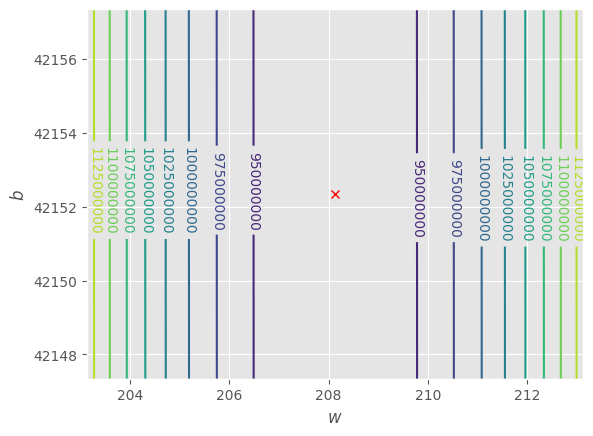

In [ ]:
simple_reg_contour_plot(X_train, Y_train, 'viridis')

## **Need for Feature Scaling**

They aren't lines; they are **ellipses**, with a significantly larger major axis than minor axis. This tells us that the MSE loss surface has **very different curvatures in different directions**: it is highly curved in one direction and relatively flat in another.

When we apply Gradient Descent to such a surface, the learning rate must be sufficiently small so that the steps in the direction of **high curvature** do not become too large and cause us to overshoot. However, such a small learning rate also means that our progress in the direction of **low curvature** is extremely slow.

This is why, even after **200,000 steps of Gradient Descent**, the algorithm can still be nowhere near the optimal point.

>So, how do we deal with this situation?

One reason for this poorly conditioned loss surface is that our features can have **very different scales**. For example, the range of house prices may be much larger than the range of the corresponding house-area values. These differences in feature scales affect the geometry of the MSE loss surface.

To deal with this, we perform **feature scaling**.


The main purpose of **feature scaling** is to transform the values of different features onto **comparable scales**.

Another key benefit is that scaling can make the geometry of the loss surface **much better conditioned** compared with the unscaled version. Instead of having highly elongated contours, we can obtain a more well-shaped loss surface, allowing Gradient Descent to converge much more efficiently.

There are several variations of feature scaling. Here, we are going to look at **three of the most important ones**:


#### **Min-Max Scaling**

In **Min-Max Scaling**, every value of a feature is transformed according to:

$$
X_{\text{norm}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}}
$$

Here, $X_{\text{min}}$ and $X_{\text{max}}$ are the minimum and maximum values of that feature, respectively.

With **Min-Max Scaling**, the minimum value of each feature is mapped to **0**, and the maximum value is mapped to **1**. Therefore, the values of each feature are transformed to lie within the range **$[0,1]$**.


In [ ]:
def min_max_scaling(X):
    x_min = (X.min(axis=0))
    x_max = (X.max(axis=0))
    return (X - x_min)/(x_max - x_min)

In [ ]:
X_train_scaled = min_max_scaling(X_train)
Y_train_scaled = min_max_scaling(Y_train)

In [ ]:
optimal_min_max = simple_reg_soln(X_train_scaled, Y_train_scaled)

In [ ]:
print(optimal_min_max)

[[ 0.99848126]
 [-0.05124258]]


In [ ]:
w_min_max = optimal_min_max[0][0]
b_min_max = optimal_min_max[1][0]

In [ ]:
simple_reg_compute_MSE(X_train_scaled, Y_train_scaled,
                       w_min_max, b_min_max)

np.float64(0.0013830315204940034)

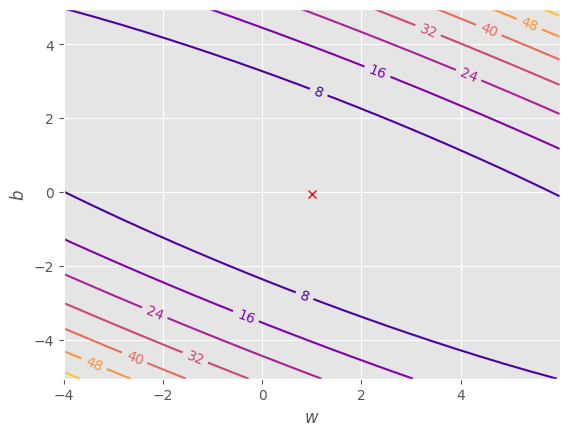

In [ ]:
simple_reg_contour_plot(X_train_scaled, Y_train_scaled, 'plasma')

#### **Better Conditioned**

By looking at the contours we can say that, the loss surface of the **Min-Max scaled features** is much better conditioned compared with the unscaled version.

By **better conditioned**, we mean that the ratio between the **major axis and minor axis** of the elliptical contours is smaller. The ideal case is when this ratio is **1**, meaning the contours are circular and the curvature is approximately the same in every direction.

As this ratio becomes larger, the difference in curvature between directions becomes greater. Consequently, Gradient Descent requires a **smaller learning rate** to avoid overshooting in the direction of high curvature, which makes convergence slower in the relatively flat direction.


In [ ]:
w_hat, b_hat = simple_reg_gradient_descent(X_train_scaled, Y_train_scaled, 0, 0,
                                           0.01, 10000)

Step number: 1000,
w:
0.7506439147196245,
b:
0.08251733954875204,
loss:
0.006001022794311536

Step number: 2000,
w:
0.9211864714695104,
b:
-0.009525927071362515,
loss:
0.0018322111215430571

Step number: 3000,
w:
0.9743747859805146,
b:
-0.03823211224337108,
loss:
0.0014267220131855976

Step number: 4000,
w:
0.9909630021680492,
b:
-0.04718491343533515,
loss:
0.001387281177306504

Step number: 5000,
w:
0.9961364865849599,
b:
-0.04997708692347252,
loss:
0.0013834448731918428

Step number: 6000,
w:
0.997749977795192,
b:
-0.050847901836111785,
loss:
0.0013830717262000986

Step number: 7000,
w:
0.9982531887214656,
b:
-0.05111948904775776,
loss:
0.0013830354311949887

Step number: 8000,
w:
0.9984101286754699,
b:
-0.051204190874126025,
loss:
0.0013830319008773786

Step number: 9000,
w:
0.9984590746499662,
b:
-0.051230607432353754,
loss:
0.0013830315574928718

Step number: 10000,
w:
0.9984743397775396,
b:
-0.05123884615138109,
loss:
0.0013830315240927836



Now let's compare the following parameters for unscaled and scaled data:

1.   **Learning rate**
2.   **Number of steps**

**Learning rate and steps for unscaled data:**

```python
simple_reg_gradient_descent(X_train, Y_train, 0, 0, 0.0000001, 2_00_000)


**Learning rate and steps for min-max scaled data:**
```python
simple_reg_gradient_descent(X_train_scaled, Y_train_scaled, 0, 0, 0.01, 10000)

The learning rate for the scaled version is $10^5$ times larger than the learning rate used for the unscaled data. This clearly demonstrates that the scaled loss surface is much better conditioned, allowing Gradient Descent to take significantly larger steps without overshooting.

Recall that even after 200,000 steps, we had not reached the optimal point for the unscaled data. In contrast, for the scaled data, we reached the optimal point after only 50,000 steps.

This demonstrates how feature scaling can significantly improve the convergence of Gradient Descent.

### **Z-score Normalization**

Z-score normalization (also known as Standardization) transforms data to have a **mean of 0 and a unit variance**.
The formula is given by

$$X_{\text{norm}} = \dfrac{X - X_{\text{$\mu$}}}{X_{σ}}$$

Where $X_{\text{$\mu$}}$ is sample mean of the feature and $X_{\text{$\sigma$}}$ is sample standard deviation of the feature.

In [ ]:
def Z_score_normalization(X):
    return (X - X.mean(axis=0))/(X.std(axis=0))

In [ ]:
X_stand = Z_score_normalization(X_train)
Y_stand = Z_score_normalization(Y_train)

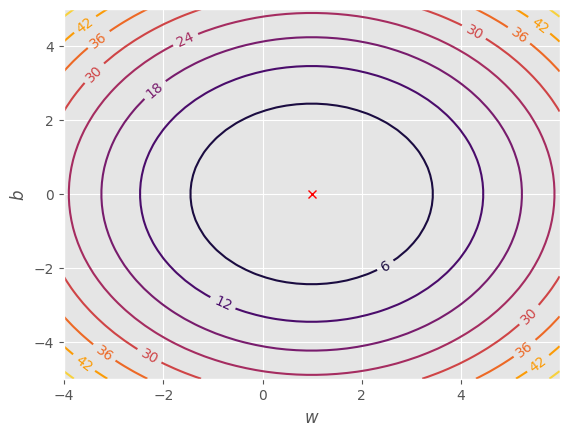

In [ ]:
simple_reg_contour_plot(X_stand, Y_stand, 'inferno')

Now, take a moment and observe that the contours are much more like circles compared with the unscaled version. **This means that the curvature is almost the same in every direction**. Consequently, the condition number is much closer to 1, indicating that the loss surface is much better conditioned.

This makes the **surface much more suitable for Gradient Descent**, allowing us to use a relatively larger learning rate and converge to the optimal point more efficiently.

In [ ]:
optimal_z_score = simple_reg_soln(X_stand, Y_stand)

In [ ]:
w_standardized = optimal_z_score[0][0]
b_standardized = optimal_z_score[1][0]
print(optimal_z_score)

[[9.90780530e-01]
 [3.42483045e-16]]


In [ ]:
simple_reg_gradient_descent(X_stand, Y_stand, 0, 0, 0.5, 50)

Step number: 5,
w:
0.9907805303507979,
b:
3.0055323309495306e-16,
loss:
0.01835394067779165

Step number: 10,
w:
0.9907805303507979,
b:
2.6962559169468085e-16,
loss:
0.01835394067779164

Step number: 15,
w:
0.9907805303507979,
b:
2.950021179718273e-16,
loss:
0.018353940677791645

Step number: 20,
w:
0.9907805303507979,
b:
2.997602166487923e-16,
loss:
0.01835394067779165

Step number: 25,
w:
0.9907805303507979,
b:
2.688325752485201e-16,
loss:
0.01835394067779164

Step number: 30,
w:
0.9907805303507979,
b:
2.7279765747932424e-16,
loss:
0.01835394067779164

Step number: 35,
w:
0.9907805303507979,
b:
2.7755575615628923e-16,
loss:
0.01835394067779165

Step number: 40,
w:
0.9907805303507979,
b:
2.918300521871841e-16,
loss:
0.018353940677791645

Step number: 45,
w:
0.9907805303507979,
b:
2.9579513441798827e-16,
loss:
0.018353940677791645

Step number: 50,
w:
0.9907805303507979,
b:
3.0055323309495326e-16,
loss:
0.01835394067779165



(np.float64(0.9907805303507979), np.float64(3.0055323309495326e-16))


*   Learning Rate = $0.5$
*   Steps = 50

The convergence is much faster compared with both the Min-Max scaled and unscaled versions.

However, this **does not mean that Z-score scaling will always outperform Min-Max scaling for every dataset**. For some datasets, Min-Max scaling may produce a better-conditioned loss surface than Z-score scaling, while for others, Z-score scaling may work better.

Therefore, **there is no single feature-scaling technique that is universally best**. The effectiveness of a scaling method depends on the characteristics of the dataset.

**The key takeaway is that different feature-scaling techniques can result in different loss-surface geometries, and some may work better than others for a particular dataset.**


### **Max Normalization**
Every feature value is transformed as follows:
$$X_{\text{norm}} = \dfrac{X}{\max(|X|)}$$

In [ ]:
def max_normalization(X):
    abs_max = (np.abs(X)).max(axis=0)
    return X/abs_max

In [ ]:
X_max_normalized = max_normalization(X_train)
Y_max_normalized = max_normalization(Y_train)

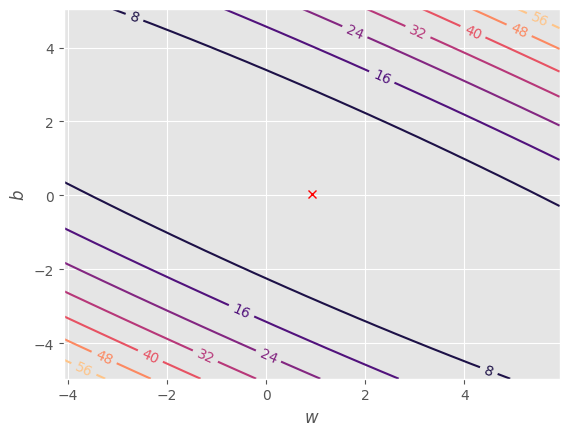

In [ ]:
simple_reg_contour_plot(X_max_normalized, Y_max_normalized, 'magma')

The contour of min-max and max-normalized are identical, so it makes sense to conclude that their learning rates and steps are also identical.

In [ ]:
optimal_max_norm = simple_reg_soln(X_max_normalized, Y_max_normalized)

In [ ]:
w_max_norm = optimal_max_norm[0][0]
b_max_norm = optimal_max_norm[1][0]
print(optimal_max_norm)

[[0.91842488]
 [0.04028644]]


In [ ]:
simple_reg_gradient_descent(X_max_normalized, Y_max_normalized,
                            0, 0, 0.01, 10000)

Step number: 1000,
w:
0.622934265717245,
b:
0.219270492546155,
loss:
0.005586568871745312

Step number: 2000,
w:
0.7849271499205013,
b:
0.12114844960966654,
loss:
0.001814352603404457

Step number: 3000,
w:
0.8581128322131707,
b:
0.0768185477400193,
loss:
0.0010444124664626755

Step number: 4000,
w:
0.8911769023974756,
b:
0.05679103770301613,
loss:
0.0008872613986807967

Step number: 5000,
w:
0.9061146976451964,
b:
0.047742942819753956,
loss:
0.000855185582756874

Step number: 6000,
w:
0.9128633443066329,
b:
0.043655164515549294,
loss:
0.0008486386468581417

Step number: 7000,
w:
0.9159122702696445,
b:
0.04180837448074933,
loss:
0.000847302363791679

Step number: 8000,
w:
0.9172897241495525,
b:
0.0409740255560227,
loss:
0.0008470296175083286

Step number: 9000,
w:
0.9179120348301968,
b:
0.040597080632628055,
loss:
0.0008469739477651807

Step number: 10000,
w:
0.9181931844126919,
b:
0.04042678320542266,
loss:
0.000846962585116114



(np.float64(0.9181931844126919), np.float64(0.04042678320542266))

So, the whole idea of feature scaling is to obtain a **better-conditioned loss surface for Gradient Descent**. This matters because, on a better-conditioned surface, Gradient Descent can converge much faster compared with an ill-conditioned surface.

# **Mean Absolute Error**

Recall the Mean absolute error loss function is:

$$\mathcal{L}(w, b) = \dfrac{1}{n}\sum_{i=1}^n \left|wx^{(i)} + b -  y^{(i)}\right|$$

Then

$$\nabla\mathcal{L}_w = \dfrac{1}{n}\sum_{i=1}^n\text{Sign}\left(wx^{(i)} + b -  y^{(i)}\right)x^{(i)}$$

$$\nabla\mathcal{L}_b = \dfrac{1}{n}\sum_{i=1}^n\text{Sign}\left(wx^{(i)} + b -  y^{(i)}\right)$$

Where Sign function defined as follows:
$$\text{Sign}(z) =
\begin{cases}1, & \text{ if } z> 0 \\
0, & \text{ if } z =  0 \\
-1, & \text{ if } z< 0 \\
\end{cases}$$

>**Note:** The absolute value function is not differentiable at $z=0$. Therefore, the derivative of the MAE loss is not defined when the prediction error is exactly zero.


## **Compute MAE Gradient**

In [ ]:
def simple_reg_gradient_MAE(X_train, Y_train, w, b):
    n = X_train.shape[0]
    y_hat = w*X_train + b
    w_grad = (1/n)*((np.sign(y_hat - Y_train)*X_train).sum())
    b_grad = (1/n)*((np.sign(y_hat - Y_train)).sum())
    return w_grad, b_grad

In [ ]:
simple_reg_gradient_MAE(X_train, Y_train, 0, 0)

(np.float64(-2685.542857142857), np.float64(-1.0))

## **MAE Gradient Descent**

In [ ]:
def simple_reg_gradient_descent_MAE(X_train, Y_train, w, b,
                                    learning_rate, steps):
    loss_func = lambda w, b: simple_reg_compute_MAE(X_train, Y_train, w, b)
    per_step = np.floor(0.1*steps)
    for step in range(1, steps+1):
        w_grad, b_grad = simple_reg_gradient_MAE(X_train, Y_train, w, b)
        w = w - learning_rate*w_grad
        b = b - learning_rate*b_grad
        if step%per_step==0:
            print(f"Step number: {step},\nw:\n{w},\nb:\n{b},\nloss:\n{loss_func(w, b)}\n")

    return w, b

In [ ]:
w_mae, b_mae = simple_reg_gradient_descent_MAE(X_train, Y_train, 0, 0,
                                               0.01, 8000)

Step number: 800,
w:
218.91371428572,
b:
1.038285714285722,
loss:
28733.986284555333

Step number: 1600,
w:
218.86971428572582,
b:
2.005714285714278,
loss:
28746.248570267962

Step number: 2400,
w:
218.82571428573164,
b:
2.973142857142813,
loss:
28758.510855980596

Step number: 3200,
w:
218.78171428573745,
b:
3.940571428571348,
loss:
28770.773141693237

Step number: 4000,
w:
218.73771428574327,
b:
4.907999999999933,
loss:
28783.035427405885

Step number: 4800,
w:
218.69371428574908,
b:
5.875428571428522,
loss:
28795.297713118518

Step number: 5600,
w:
220.3017142857549,
b:
6.8434285714285386,
loss:
28442.85677076766

Step number: 6400,
w:
220.25771428576073,
b:
7.810857142857127,
loss:
28447.905538113915

Step number: 7200,
w:
220.21371428576654,
b:
8.778285714285763,
loss:
28452.954305460175

Step number: 8000,
w:
220.16971428577236,
b:
9.74571428571441,
loss:
28458.003072806416



In [ ]:
simple_reg_compute_MAE(X_train, Y_train, w_mae, b_mae)

np.float64(28458.003072806416)

## **MAE Contour Plot**

In [ ]:
def simple_reg_contour_plot_MAE(X_train, Y_train, w_hat, b_hat):
    w_val = np.linspace(w_hat -5, w_hat + 5)
    b_val = np.linspace(b_hat -5, b_hat + 5)
    W, B = np.meshgrid(w_val, b_val)
    loss_func = np.vectorize(lambda w, b: simple_reg_compute_MAE(X_train,
                                                                 Y_train,
                                                                 w, b))
    contour = plt.contour(W, B, loss_func(W, B), levels=8, cmap='viridis')
    contour.clabel()
    plt.plot(w_hat, b_hat, 'x', color='red')
    plt.xlabel(r'$w$')
    plt.ylabel(r'$b$')
    plt.show()

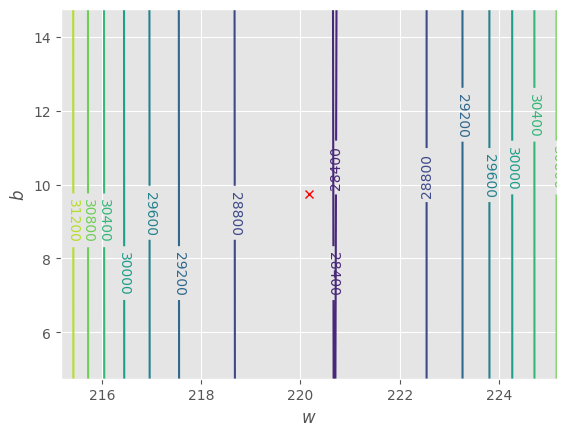

In [ ]:
simple_reg_contour_plot_MAE(X_train, Y_train, w_mae, b_mae)

## **MAE for Scaled Data**

In [ ]:
w_stand_mae, b_stand_mae = simple_reg_gradient_descent_MAE(X_stand, Y_stand,
                                                           0, 0, 0.5, 200)

Step number: 20,
w:
0.9547200857578634,
b:
-0.2285714285714286,
loss:
0.23616733103397783

Step number: 40,
w:
1.0032918397763946,
b:
-0.17142857142857143,
loss:
0.18467578904327783

Step number: 60,
w:
0.9515690483399911,
b:
-0.2285714285714286,
loss:
0.2365288297140738

Step number: 80,
w:
1.051346304843517,
b:
-0.2,
loss:
0.20537120558297586

Step number: 100,
w:
0.9658944426639506,
b:
-0.2,
loss:
0.20997780509120467

Step number: 120,
w:
1.0481952674256447,
b:
-0.2,
loss:
0.20535263131218048

Step number: 140,
w:
0.9627434052460784,
b:
-0.2,
loss:
0.21021587117860357

Step number: 160,
w:
0.9533849004113052,
b:
-0.2285714285714286,
loss:
0.23632050844079838

Step number: 180,
w:
1.053162156914831,
b:
-0.2,
loss:
0.2053819094000444

Step number: 200,
w:
0.9502338629934329,
b:
-0.2285714285714286,
loss:
0.2366820071208943



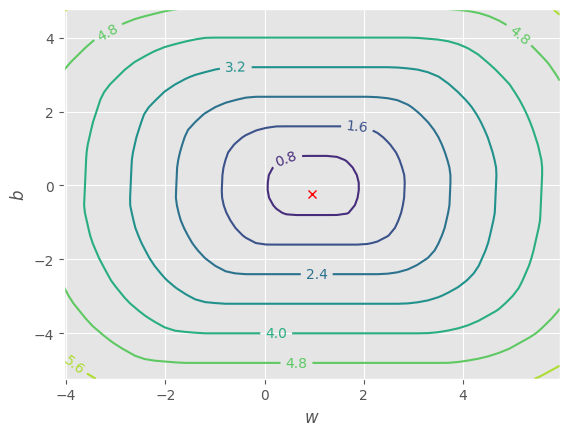

In [ ]:
simple_reg_contour_plot_MAE(X_stand, Y_stand, w_stand_mae, b_stand_mae)

In [ ]:
w_min_max_mae, b_min_max_mae = simple_reg_gradient_descent_MAE(X_train_scaled,
                                                               Y_train_scaled,
                                                               0, 0,
                                                               0.01, 10000)

Step number: 1000,
w:
0.9510737561827093,
b:
-0.024285714285713383,
loss:
0.02987272942120882

Step number: 2000,
w:
0.9591511492580441,
b:
-0.027714285714284803,
loss:
0.02987236188998318

Step number: 3000,
w:
0.9674461739888924,
b:
-0.030571428571427653,
loss:
0.029855948171298486

Step number: 4000,
w:
0.9726380564445,
b:
-0.03228571428571336,
loss:
0.029858577533355066

Step number: 5000,
w:
0.9727669479196001,
b:
-0.03228571428571336,
loss:
0.02986026035718456

Step number: 6000,
w:
0.9726236543496026,
b:
-0.03228571428571336,
loss:
0.02985843432951652

Step number: 7000,
w:
0.9727525458247027,
b:
-0.03228571428571336,
loss:
0.02985971593154199

Step number: 8000,
w:
0.9726092522547053,
b:
-0.03228571428571336,
loss:
0.029858291125677956

Step number: 9000,
w:
0.9727381437298054,
b:
-0.03228571428571336,
loss:
0.02985957272770342

Step number: 10000,
w:
0.972594850159808,
b:
-0.03228571428571336,
loss:
0.02985814792183941



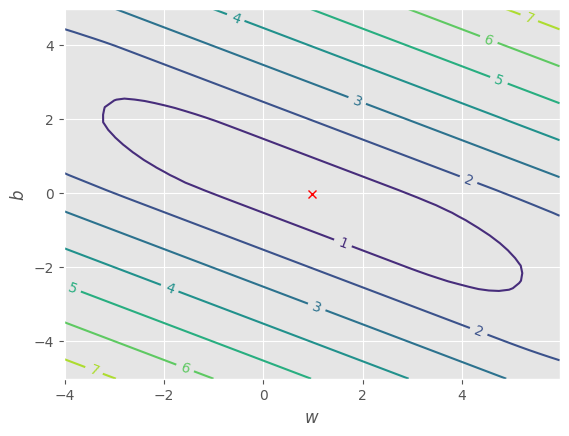

In [ ]:
simple_reg_contour_plot_MAE(X_train_scaled, Y_train_scaled,
                            w_min_max_mae, b_min_max_mae)

In [ ]:
w_max_mae, b_max_mae = simple_reg_gradient_descent(X_max_normalized,
                                                   Y_max_normalized,
                                                   0, 0,
                                                   0.01,
                                                   10000)

Step number: 1000,
w:
0.622934265717245,
b:
0.219270492546155,
loss:
0.005586568871745312

Step number: 2000,
w:
0.7849271499205013,
b:
0.12114844960966654,
loss:
0.001814352603404457

Step number: 3000,
w:
0.8581128322131707,
b:
0.0768185477400193,
loss:
0.0010444124664626755

Step number: 4000,
w:
0.8911769023974756,
b:
0.05679103770301613,
loss:
0.0008872613986807967

Step number: 5000,
w:
0.9061146976451964,
b:
0.047742942819753956,
loss:
0.000855185582756874

Step number: 6000,
w:
0.9128633443066329,
b:
0.043655164515549294,
loss:
0.0008486386468581417

Step number: 7000,
w:
0.9159122702696445,
b:
0.04180837448074933,
loss:
0.000847302363791679

Step number: 8000,
w:
0.9172897241495525,
b:
0.0409740255560227,
loss:
0.0008470296175083286

Step number: 9000,
w:
0.9179120348301968,
b:
0.040597080632628055,
loss:
0.0008469739477651807

Step number: 10000,
w:
0.9181931844126919,
b:
0.04042678320542266,
loss:
0.000846962585116114



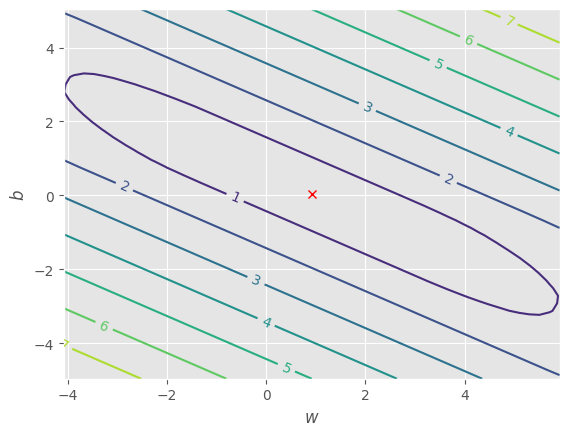

In [ ]:
simple_reg_contour_plot_MAE(X_max_normalized, Y_max_normalized,
                            w_max_mae, b_max_mae)

# **Multiple Linear Regression**



## **The Idea**
So far, in simple linear regression, we have considered only one feature and tried to find the **best possible linear relationship** between that feature and the target variable.

However, in real-world problems, the target variable is often influenced by **multiple features**.

For example, when predicting the price of a house, factors such as the **number of bedrooms, house size, distance to the nearest city, number of nearby amenities**, and many others may influence its price.

This is where **Multiple Linear Regression** comes in. Instead of using a single feature to make predictions, we use multiple features simultaneously to model the relationship between the features and the target variable.

In [ ]:
multiple_reg_df = pd.read_csv('house_price_regression_dataset.csv').head(50)
multiple_reg_df

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
5,3944,5,3,1990,2.475930,2,8,8.797970e+05
6,3671,1,2,2012,4.911960,0,1,8.144279e+05
7,3419,1,1,1972,2.805281,1,1,7.034131e+05
8,630,3,3,1997,1.014286,1,8,1.738750e+05
9,2185,4,2,1981,3.941604,2,5,5.041765e+05


In [ ]:
multiple_reg_data = multiple_reg_df.to_numpy()

I am sticking to the frist two features of the data, its because we can plot data points in 3D space when we have two features, otherwise it's not possible to visualize the data points.

In [ ]:
X = multiple_reg_data[:, :2]
Y = multiple_reg_data[:, -1].reshape(-1, 1)

In [ ]:
print(X.shape, Y.shape)

(50, 2) (50, 1)


## **Train and Test Split**

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y,
                                                    test_size=0.3,
                                                    random_state=42)

In [ ]:
print(X_train.shape, Y_train.shape)

(35, 2) (35, 1)


## **Intro**

In multiple linear regression, we have multiple features, $X_1, \ldots, X_n$, and a target variable $Y$. The task is the same as in simple linear regression: we want to find the **best** possible linear relationship between $X_1, \ldots, X_n$ and $Y$.

That is,

$$
w_1X_1 + \ldots + w_nX_n + b \approx Y
$$

How do we define the **best**?

Just like we did in simple linear regression, we want to find the set of parameters that keeps the loss as low as possible. Again here we are going to use two different loss function: **MSE** and **MAE**.

### **The Conventions**

For a multiple linear regression model, we collect all the parameter values $w_i$ into a single **weight vector**. The bias term $b$ is kept separate and is not included in this vector.

That is,

$$
\hat{\mathbf{w}} =
\begin{bmatrix}
w_1 \\
\vdots \\
w_n
\end{bmatrix}
$$

where $\mathbf{w}$ contains the weights corresponding to the features $X_1,\ldots,X_n$, while $b$ represents the bias term separately.

Each data point is denoted as follows:

$$
\left((x_1^{(i)}, \ldots, x_n^{(i)}), y^{(i)}\right)
$$

where $i$ denotes the $i$-th data point, and $x_j^{(i)}$ represents the value of the $j$-th feature for that data point and


$$\mathrm{x}^{(i)} = \begin{bmatrix}x_1^{(i)}\\ \vdots \\ x_n^{(i)} \end{bmatrix}$$

## **Loss Functions**

### **Mean Squared Error**

 $$\mathcal{L}(\hat{\mathrm{w}}, b) =
 \dfrac{1}{m}\sum_{i = 1}^m\left(\hat{\mathrm{w}}^T\mathrm{x}^{(i)} + b  - y^{(i)} \right)^2$$

Notice that MSE can be written in matrix form as follows:
$$\mathcal{L}(\hat{\mathrm{x}}) = \dfrac{1}{m}||A\hat{\mathrm{x}} - \mathrm{y}||_2^2 = \dfrac{1}{m}(A\hat{\mathrm{x}} - \mathrm{y})^T(A\hat{\mathrm{x}} - \mathrm{y})$$
where

$$
A =\begin{bmatrix}x_1^{(1)} & \ldots & x_n^{(1)} & 1 \\ \vdots & \vdots & \vdots & 1 \\ x_1^{(m)} & \ldots & x_n^{(m)} & 1 \end{bmatrix}$$


$$\hat{\mathrm{x}} = \begin{bmatrix}\hat{\mathrm{w}} \\ b \end{bmatrix}, \mathrm{y} = \begin{bmatrix}y^{(1)} & \ldots & y^{(m)} \end{bmatrix}^T$$

 ### **Mean Absolute Error**
  $$\mathcal{L}(\hat{\mathrm{w}}, b) =
 \dfrac{1}{m}\sum_{i = 1}^m\left|\hat{\mathrm{w}}^T\mathrm{x}^{(i)} + b  - y_i \right|$$

In [ ]:
m = X_train.shape[0] #Number of training instances
n = X_train.shape[1] #Number of features

In [ ]:
def multiple_reg_compute_MSE(x_train, y_train, w_hat, b):
    m = x_train.shape[0] #Number of training examples.
    Y_hat = (x_train@w_hat  + b)
    loss = (1/m)*((Y_hat - y_train).T@(Y_hat - y_train))
    return loss


In [ ]:
def multiple_reg_compute_MAE(x_train, y_train, w_hat, b):
    m = x_train.shape[0]
    Y_hat = (x_train@w_hat + b)
    loss = (1/m)*((np.abs(Y_hat - y_train)).sum())
    return loss

In [ ]:
w_hat = np.ones((n, 1))
b = 0

In [ ]:
multiple_reg_compute_MSE(X_train, Y_train, w_hat, b)

array([[4.08152067e+11]])

In [ ]:
multiple_reg_compute_MAE(X_train, Y_train, w_hat, b)

np.float64(598421.1287866938)

## **Mean Squared Error**

For this section we choose the MSE as our loss function.

### **Normal Equation**
Since loss can be written as follows:

$$\mathcal{L}(\hat{\mathrm{x}}) = \dfrac{1}{m}||A\hat{\mathrm{x}} - \mathrm{y}||_2^2 = \dfrac{1}{m}(A\hat{\mathrm{x}} - \mathrm{y})^T(A\hat{\mathrm{x}} - \mathrm{y})$$
where

$$
A =\begin{bmatrix}x_1^{(1)} & \ldots & x_n^{(1)} & 1 \\ \vdots & \vdots & \vdots & \vdots \\ x_1^{(m)} & \ldots & x_n^{(m)} & 1 \end{bmatrix}$$

We already say the gradient for this function in simple regression:
$$\nabla \mathcal{L}= \dfrac{2}{m}A^T(A\hat{\mathrm{x}}- \mathrm{y})$$

> Since MSE is convex differentiable function, whenever the gradient equals to zero vector Then MSE has global minima at that point.

To find out those points, all we have to solve is the following system:
$$A^TA \hat{\mathrm{x}} = A^T \mathrm{y}$$

We already seen in the above, this is a **consistent system(solvable) and Uniqueness depends on linear dependence relation of columns of** $A$. So to find out the parameters all we call to is numpy least squares function that's all.

In [ ]:
def multiple_reg_soln(X_train, Y_train):

    ones_col = np.ones((X_train.shape[0], 1))
    X_aug = np.hstack((X_train, ones_col))

    soln = np.linalg.lstsq(X_aug, Y_train, rcond=None)[0]

    return soln

### **The Plot**

In [ ]:
def multiple_reg_plot(X_train, Y_train, w_hat, b):
    # Data Points Plot
    X_1 = X_train[:, 0].reshape(-1, 1)
    X_2 = X_train[:, 1].reshape(-1, 1)
    fig, ax = plt.subplots(subplot_kw={'projection':'3d'}, figsize=(7, 7))
    ax.scatter(X_1, X_2, Y_train, marker='x', label='Data Points', color='red')

    # Regression Plane
    x_val = np.linspace(X_1.min(), X_1.max())
    y_val = np.linspace(X_2.min(), X_2.max())
    X, Y = np.meshgrid(x_val, y_val)
    Z = X*w_hat[0][0] + Y*w_hat[1][0] + b
    ax.plot_surface(X, Y, Z,cmap='viridis', antialiased=False, alpha=0.5)


    ax.set_xlabel(r'$x_1$')
    ax.set_ylabel(r'$x_2$')
    ax.set_zlabel(r'$y$')
    ax.set_title('Multiple Linear Regression Plot')
    ax.view_init(25)
    ax.legend()
    plt.show()



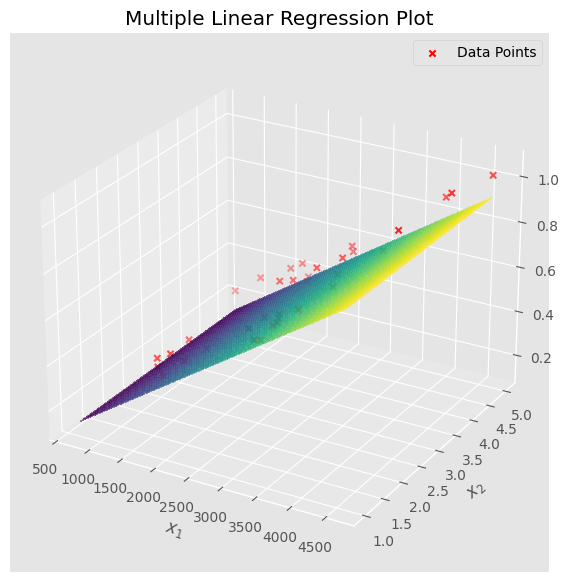

In [ ]:
multiple_reg_plot(X_train, Y_train, np.array([[200], [20]]), 100)

### **Gradient of MSE**

$$\dfrac{\partial \mathcal{L}}{\partial w_j} = \dfrac{2}{m}\sum_{i=1}^m\left( \hat{\mathrm{w}}^T\mathrm{x}^{(i)} + b  - y^{(i)}\right)\mathrm{x}_j^{(i)}$$

$$\text{for }j =1, \ldots, n$$

$$\dfrac{\partial \mathcal{L}}{\partial b} = \dfrac{2}{m}\sum_{i=1}^m\left( \hat{\mathrm{w}}^T\mathrm{x}^{(i)} + b  - y^{(i)}\right)$$

**Q)** There is some challenge, since we are packing all the $w_i$'s into a single column vector, can you somehow compactly write all the partial derivative of loss function MSE with resepect to $w_i$'s into a single column vector?

**Ans)**

$$\nabla \mathcal{L}_{\hat{\mathrm{w}}} = \dfrac{2}{m}\left( \mathrm{X}^T(\mathrm{y}_{\text{Pred}} - \mathrm{y}) \right)$$
where:
$$\mathrm{X} = \begin{bmatrix}\leftarrow & \mathrm{x}^{(1)} & \rightarrow \\
\vdots & \vdots & \vdots \\
\leftarrow & \mathrm{x}^{(m)} & \rightarrow
\end{bmatrix}$$
and
$$\mathrm{y}_{\text{Pred}} = \mathrm{X}\hat{\mathrm{w}} + b\mathrm{1} $$

In [ ]:
def multiple_reg_gradient_MSE(X_train, Y_train, w_hat, b):
    """
    Compute the gradient of MSE loss at given w_hat and b
    """
    m = X_train.shape[0]  # number of training instances
    Y_pred = X_train @ w_hat + b  # NumPy broadcasting

    w_grad = (2 / m) * (X_train.T @ (Y_pred - Y_train))
    b_grad = (2 / m) * (Y_pred - Y_train).sum()

    return w_grad, b_grad

In [ ]:
multiple_reg_gradient_MSE(X_train, Y_train, w_hat, b)

(array([[-3.68842014e+09],
        [-3.51362627e+06]]),
 np.float64(-1196842.2575733876))

### **Gradient Descent**

In [ ]:
def multiple_reg_gradient_descent_mse(X_train, Y_train, w_hat, b,
                                      learning_rate, steps):
    loss_func = lambda w_hat, b: multiple_reg_compute_MSE(X_train, Y_train,
                                                          w_hat, b)
    per_step = np.floor(0.1*steps)
    for step in range(1, steps+1):
        w_grad, b_grad = multiple_reg_gradient_MSE(X_train, Y_train, w_hat, b)
        w_hat = w_hat - learning_rate*w_grad
        b = b - learning_rate*b_grad
        if step%per_step==0:
            print(f"Step Number: {step},\nw:\n{w_hat},\nb:\n{b},\nloss:\n{loss_func(w_hat, b)}\n")
    return w_hat, b


In [ ]:
w_hat = np.zeros((n,1))
b = 0

In [ ]:
multiple_reg_gradient_descent_mse(X_train, Y_train, w_hat, b,
                                  0.0000001, 8_00_000)

Step Number: 80000,
w:
[[221.11874497]
 [572.5815082 ]],
b:
89.93064819067584,
loss:
[[1.1286375e+09]]

Step Number: 160000,
w:
[[ 220.59269402]
 [1107.3815496 ]],
b:
174.95743829061786,
loss:
[[1.09196844e+09]]

Step Number: 240000,
w:
[[ 220.10084289]
 [1607.06488221]],
b:
255.4665582066166,
loss:
[[1.05993558e+09]]

Step Number: 320000,
w:
[[ 219.6409547 ]
 [2073.92874787]],
b:
331.75235675148144,
loss:
[[1.03195223e+09]]

Step Number: 400000,
w:
[[ 219.21093889]
 [2510.1201186 ]],
b:
404.0899297742513,
loss:
[[1.00750596e+09]]

Step Number: 480000,
w:
[[ 218.80884165]
 [2917.64552614]],
b:
472.73637955465,
loss:
[[9.86149158e+08]]

Step Number: 560000,
w:
[[ 218.43283698]
 [3298.38024864]],
b:
537.9319918165714,
loss:
[[9.67490874e+08]]

Step Number: 640000,
w:
[[ 218.08121831]
 [3654.07689634]],
b:
599.9013357495841,
loss:
[[9.51189626e+08]]

Step Number: 720000,
w:
[[ 217.75239072]
 [3986.37343566]],
b:
658.8542920744833,
loss:
[[9.36947146e+08]]

Step Number: 800000,
w:
[[ 217.4

(array([[ 217.4448636 ],
        [4296.80068839]]),
 np.float64(714.9870138600668))

In [ ]:
optimal_unscaled = multiple_reg_soln(X_train, Y_train)

In [ ]:
w_hat = optimal_unscaled[:n]
b = optimal_unscaled[n]

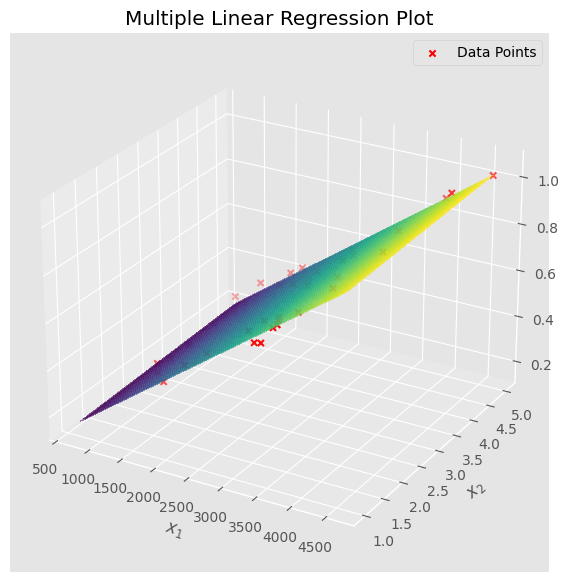

In [ ]:
multiple_reg_plot(X_train, Y_train, w_hat, b)

### **Feature Scaling**

#### **Min-Max Scaling**

In [ ]:
X_train_min_max = min_max_scaling(X_train)
Y_train_min_max = min_max_scaling(Y_train)

In [ ]:
optimal_min_max = multiple_reg_soln(X_train_min_max, Y_train_min_max)

In [ ]:
print(optimal_min_max)

[[ 1.00833984]
 [ 0.03378928]
 [-0.07338954]]


In [ ]:
w_hat_min_max = optimal_min_max[:n, ::]
b_min_max = optimal_min_max[n, ::]

In [ ]:
multiple_reg_gradient_descent_mse(X_train_min_max, Y_train_min_max,
                               w_hat, b,
                               0.01, 5_000)

Step Number: 500,
w:
[[-3455.95185414]
 [ -764.35720016]],
b:
[2238.02822378],
loss:
[[863379.23858909]]

Step Number: 1000,
w:
[[-2035.8160028 ]
 [ -684.60434564]],
b:
[1447.433754],
loss:
[[317763.33408422]]

Step Number: 1500,
w:
[[-1240.91095604]
 [ -480.04715195]],
b:
[916.96477407],
loss:
[[122915.7879382]]

Step Number: 2000,
w:
[[-767.41571706]
 [-313.19346501]],
b:
[576.23332999],
loss:
[[47947.88850089]]

Step Number: 2500,
w:
[[-477.33540023]
 [-199.07015368]],
b:
[360.94315587],
loss:
[[18729.66358128]]

Step Number: 3000,
w:
[[-297.49621902]
 [-125.2572332 ]],
b:
[225.78795883],
loss:
[[7317.92433058]]

Step Number: 3500,
w:
[[-185.45596433]
 [ -78.49389336]],
b:
[141.15824491],
loss:
[[2859.313403]]

Step Number: 4000,
w:
[[-115.51573218]
 [ -49.10560166]],
b:
[88.2206773],
loss:
[[1117.21911493]]

Step Number: 4500,
w:
[[-71.82098584]
 [-30.69581381]],
b:
[55.12095354],
loss:
[[436.53174114]]

Step Number: 5000,
w:
[[-44.51408966]
 [-19.17816044]],
b:
[34.42850216],
loss

(array([[-44.51408966],
        [-19.17816044]]),
 array([34.42850216]))

Let's compare the learning rates and steps for scaled and unscaled versions:


For Unscaled Version:

```python
multiple_reg_gradient_descent_mse(X_train, Y_train, w_hat, b, 0.0000001, 8_00_000)

For Min-Max Transformed Version:
```python
multiple_reg_gradient_descent_mse(X_train_min_max, Y_train_min_max, w_hat, b, 0.01, 5_000)

The reason is same, transformation made the surface more conditioned, so that gradient descent can move at faster rate towards the optimal point. Let's get the contour plots of loss function near the optimal point by holding the bias term fixed.

In [ ]:
def multiple_reg_contour_plot(x_train, y_train, colormap):

    """
    Plot the contour of MSE centered at optimal point by holding b fixed.
    """

    optimal = multiple_reg_soln(x_train, y_train)

    n = x_train.shape[1]

    w_hat = optimal[:n]
    b_ = optimal[n]

    w1_val = np.linspace(w_hat[0] - 5, w_hat[0] + 5)
    w2_val = np.linspace(w_hat[1] - 5, w_hat[1] + 5)

    W1, W2 = np.meshgrid(w1_val, w2_val)

    loss_func = np.vectorize(
        lambda w1, w2: multiple_reg_compute_MSE(
            x_train,
            y_train,
            np.array([[w1], [w2]]),
            b_
        )
    )

    contour = plt.contour(
        W1,
        W2,
        loss_func(W1, W2),
        levels=8,
        cmap=colormap
    )

    contour.clabel()

    plt.plot(w_hat[0], w_hat[1], 'x', color='red')

    plt.xlabel(r'$w_1$')
    plt.ylabel(r'$w_2$')

    plt.show()

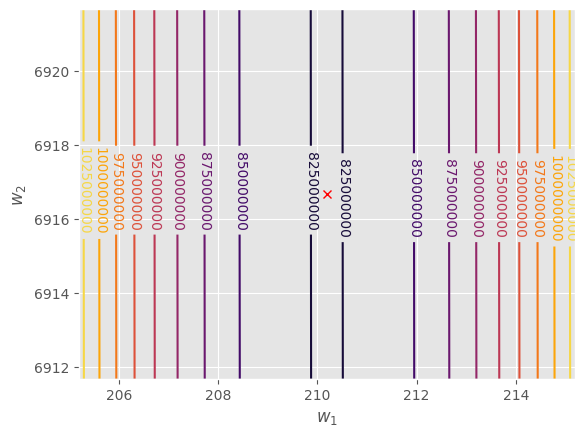

In [ ]:
multiple_reg_contour_plot(X_train, Y_train, 'inferno')

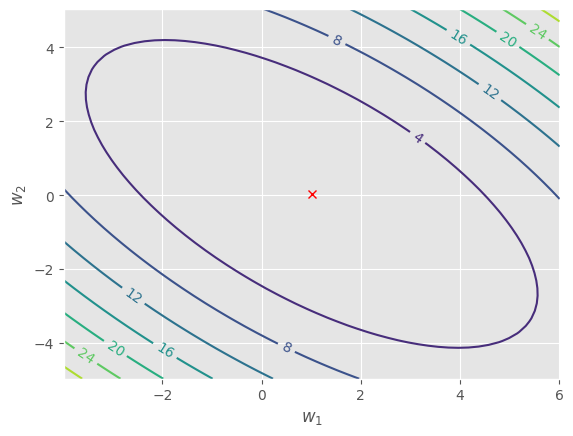

In [ ]:
multiple_reg_contour_plot(X_train_min_max, Y_train_min_max, 'viridis')

In [ ]:
optimal_min_max = multiple_reg_soln(X_train_min_max, Y_train_min_max)

In [ ]:
w_hat_min_max = optimal_min_max[:n]
b_min_max =optimal_min_max[n]

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


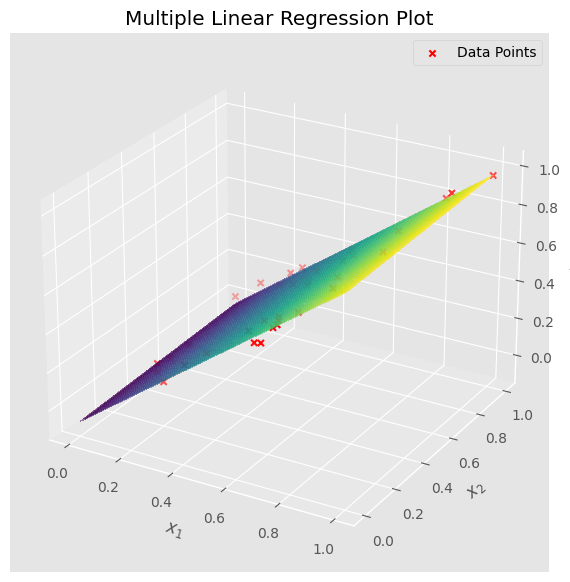

In [ ]:
multiple_reg_plot(X_train_min_max, Y_train_min_max, w_hat_min_max, b_min_max)

#### **Z-score Standardization**

In [ ]:
X_standardized = Z_score_normalization(X_train)
Y_standardized = Z_score_normalization(Y_train)

In [ ]:
multiple_reg_gradient_descent_mse(X_standardized, Y_standardized, w_hat, b,
                                  0.01, 500)

Step Number: 50,
w:
[[ 626.85902001]
 [2593.20328813]],
b:
[5712.29607284],
loss:
[[39059549.69578332]]

Step Number: 100,
w:
[[ 439.57410983]
 [1015.63089882]],
b:
[2080.24503341],
loss:
[[5362652.13572644]]

Step Number: 150,
w:
[[244.83227375]
 [413.11601617]],
b:
[757.56216832],
loss:
[[761349.87418623]]

Step Number: 200,
w:
[[124.55605094]
 [173.2394517 ]],
b:
[275.88117248],
loss:
[[112314.83411923]]

Step Number: 250,
w:
[[60.74779695]
 [74.35226878]],
b:
[100.46755833],
loss:
[[17305.74366358]]

Step Number: 300,
w:
[[29.14412157]
 [32.45989991]],
b:
[36.58723857],
loss:
[[2795.23012183]]

Step Number: 350,
w:
[[14.05241164]
 [14.35050339]],
b:
[13.32396297],
loss:
[[473.48486085]]

Step Number: 400,
w:
[[6.99582256]
 [6.40882308]],
b:
[4.85218333],
loss:
[[83.84013703]]

Step Number: 450,
w:
[[3.73796229]
 [2.89136445]],
b:
[1.76701805],
loss:
[[15.43032826]]

Step Number: 500,
w:
[[2.24569111]
 [1.32295275]],
b:
[0.6434944],
loss:
[[2.93791601]]



(array([[2.24569111],
        [1.32295275]]),
 array([0.6434944]))

In [ ]:
multiple_reg_soln(X_standardized, Y_standardized)

array([[1.00056307e+00],
       [4.62241040e-02],
       [3.42483045e-16]])

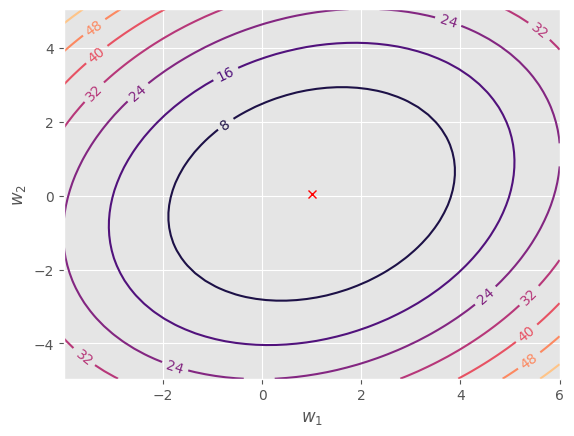

In [ ]:
multiple_reg_contour_plot(X_standardized, Y_standardized, 'magma')

Just as we expected, transforming the features produces a better-conditioned loss surface, making it more suitable for gradient descent.

## **Mean Absolute Error**

$$\mathcal{L}(\mathrm{w}, \mathrm{b}) = \dfrac{1}{n}\left(\sum_{i=1}^{m}\left|\mathrm{w}^T\mathrm{x_i}+ \mathrm{b} - \mathrm{y_i}\right| \right)$$
Let't write this is in matrix form:
$$\mathcal{L}(\mathrm{w}, \mathrm{b}) = \dfrac{1}{n}\left(\left|\mathrm{X}\mathrm{w} + \mathrm{b}^{⃗} - \mathrm{Y}\right| \right)^T1$$
where:
$$1 = \begin{bmatrix}1 & 1& \ldots 1\end{bmatrix}^T$$
$$X \text{ is data matrix of features}$$
$$Y \text{ is column vector of labels.}$$

In [ ]:
n = X_train.shape[1]

In [ ]:
w_hat = np.zeros((n, 1))
b = 0

In [ ]:
multiple_reg_compute_MAE(X_train, Y_train, w_hat, b)

np.float64(601109.7002152653)

### **Gradient of Mean Absolute Error**
For $j = 1, \ldots, n$:

$$\dfrac{\partial \mathcal{L}}{\partial w_j} = \dfrac{1}{m}\sum_{i=1}^{m}\left(\text{sign}\left(\mathrm{w}^T\mathrm{x_i} + b - \mathrm{y}\right)\mathrm{x_i}^{(j)}\right)$$
We can all these paritial derivative into a column vector as follows:
$$\nabla \mathcal{L}_{\mathrm{w}} = \dfrac{1}{m}\left(\text{sign}\left(\mathrm{X}w + b - \mathrm{Y} \right)^T \mathrm{X}\right)^T$$

$$ =  \dfrac{1}{m}\mathrm{X}^T \text{sign}\left(\hat{\mathrm{Y}} - \mathrm{Y} \right)$$
and
$$\nabla \mathcal{L}_\mathrm{b} = \dfrac{1}{m}\sum_{i=1}^{m}\left(\text{sign}\left(\mathrm{w}^T\mathrm{x_i} + b - \mathrm{y_i} \right) \right)$$

Recall the sign function is defined as follows:
$$\text{sign}(x) = \begin{cases}1, & \text{if } x > 0 \\ 0, & \text{if } x =0 \\ -1, & \text{if } x<0 \end{cases}$$

In [ ]:
def multiple_reg_gradient_MAE(X_train, Y_train, w, b):
    n = X_train.shape[0]
    residual = (X_train@w + b - Y_train)
    grad_w_T = (np.sign(residual).T)@X_train
    grad_w = (1/n)*(grad_w_T.T)
    grad_b = (1/n)*(np.sign(residual)).sum()
    return grad_w, grad_b

In [ ]:
multiple_reg_gradient_MAE(X_train, Y_train, w_hat, b)

(array([[-2685.54285714],
        [   -3.02857143]]),
 np.float64(-1.0))

### **Gradient Descent**


In [ ]:
def multiple_reg_gradient_descent_MAE(X_train, Y_train, w, b, learning_rate, steps):
    loss = lambda w, b: multiple_reg_compute_MAE(X_train, Y_train, w, b)
    per_step = np.floor(0.1*steps)
    for step in range(1, steps+1):
        w_grad, b_grad = multiple_reg_gradient_MAE(X_train, Y_train, w, b)
        w = w - learning_rate*w_grad
        b = b - learning_rate*b_grad
        if step%per_step==0:
            print(f"step Number:{step}\nw:{w}\nb:{b}\nloss:{loss(w, b)}\n")
    return w, b

In [ ]:
multiple_reg_gradient_descent_MAE(X_train, Y_train, w_hat, b,
                                  0.0001, 5000)

step Number:500
w:[[134.27714286]
 [  0.15142857]]
b:0.050000000000000405
loss:240502.16972546768

step Number:1000
w:[[220.71905714]
 [  0.26257714]]
b:0.08352571428571572
loss:28394.36863542529

step Number:1500
w:[[220.75634857]
 [  0.30480571]]
b:0.0894000000000018
loss:28392.274271716706

step Number:2000
w:[[220.74087429]
 [  0.34697714]]
b:0.0952628571428593
loss:28391.71304064887

step Number:2500
w:[[220.75178286]
 [  0.38917714]]
b:0.10113142857143109
loss:28391.549078085187

step Number:3000
w:[[220.73630857]
 [  0.43134857]]
b:0.1069942857142886
loss:28392.167636403046

step Number:3500
w:[[220.74721714]
 [  0.47354857]]
b:0.11286285714286039
loss:28390.839839014847

step Number:4000
w:[[220.75812571]
 [  0.51574857]]
b:0.11873142857143218
loss:28392.386472372586

step Number:4500
w:[[220.74265143]
 [  0.55792   ]]
b:0.12459428571428968
loss:28391.29443476903

step Number:5000
w:[[220.75356]
 [  0.60012]]
b:0.13046285714286435
loss:28391.661278741078



(array([[220.75356],
        [  0.60012]]),
 np.float64(0.13046285714286435))

**Now, if you want to try Gradient Descent on the scaled data, go ahead!**


**Happy Learnings!!!**
